# PyFC: Scaling to Many Parameters

PyFC is built to handle **arbitrary $N$-dimensional** physics models -- you provide the full
parameter space via the `grids` argument (one 1D array of test values per parameter), and the
orchestrator automatically:

* **1D intervals**: iterates through every parameter in `grids`, profiling (maximizing the
  likelihood over) all the *other* parameters at each grid point.
* **2D intervals**: scans every unique *pair* of parameters, profiling out the rest.

The 1D cost grows only *linearly* with the number of parameters $n$ (one scan per parameter).
The 2D cost grows *combinatorially*: $\binom{n}{2} = n(n-1)/2$ pairs, each needing its own
full grid of fits and toys. For $n=5$ that's already 10 pairs; for $n=10$ it's 45. This
notebook demonstrates both regimes -- a genuinely-run 5-parameter case with 2D contours, and
a 10-parameter case run 1D-only (to make the combinatorial-growth point concrete without
actually paying its cost).

As in the other tutorial notebooks, grids/`n_toys` here are kept small purely for speed; scale
them up for a real analysis.

In [1]:
%matplotlib inline

import numpy as np
from numba import njit

from pyfc import compute_fc_intervals

np.random.seed(20260727)

N_TOYS = 15
CORES = 2


def print_1d_bounds(results, n_params, cl_list):
    for p_idx in range(n_params):
        test_pts = results[f"1d_test_p{p_idx+1}"]
        print(f"  param{p_idx+1}:")
        for cl in cl_list:
            accepted = results[f"1d_accepted_p{p_idx+1}"][cl]
            accepted_pts = test_pts[accepted]
            if len(accepted_pts) == 0:
                print(f"    CL {cl}: no accepted points (empty interval)")
            else:
                print(f"    CL {cl}: [{accepted_pts.min():.4g}, {accepted_pts.max():.4g}]")

Numba detected: JIT compilation enabled for maximum speed.


## 1. Five parameters, with 2D contours

A single pair of templates (signal + background) can't identify 5 independent parameters --
with only 2 degrees of freedom in the *shape* of the templates, several parameter combinations
would produce the exact same $\mu$, and the fit would be degenerate. To make this a genuinely
identifiable 5-parameter problem, each parameter needs to move the expected counts in a
**distinguishable** way across bins:

* `params[0]`, `params[1]` scale the signal and background templates (as usual).
* `params[2..4]` are 3 "systematic" nuisance parameters, each added as a flat shift -- since
  they don't depend on the bin templates, they're only weakly constrained individually, but
  including them exercises the profiling machinery over a genuinely 5-dimensional space.

Running 5-parameter binned analysis (1D + 2D)...



--- 1D interval bounds (5-parameter) ---
  param1:
    CL 0.68: [0.501, 0.501]
    CL 0.9: [0.501, 0.501]
  param2:
    CL 0.68: [1.1, 1.299]
    CL 0.9: [0.9002, 1.299]
  param3:
    CL 0.68: [0.501, 0.501]
    CL 0.9: [0.501, 1.299]
  param4:
    CL 0.68: [0.501, 0.501]
    CL 0.9: [0.501, 1.499]
  param5:
    CL 0.68: [0.501, 0.501]
    CL 0.9: [0.501, 0.7006]

2D pairs actually computed: 10


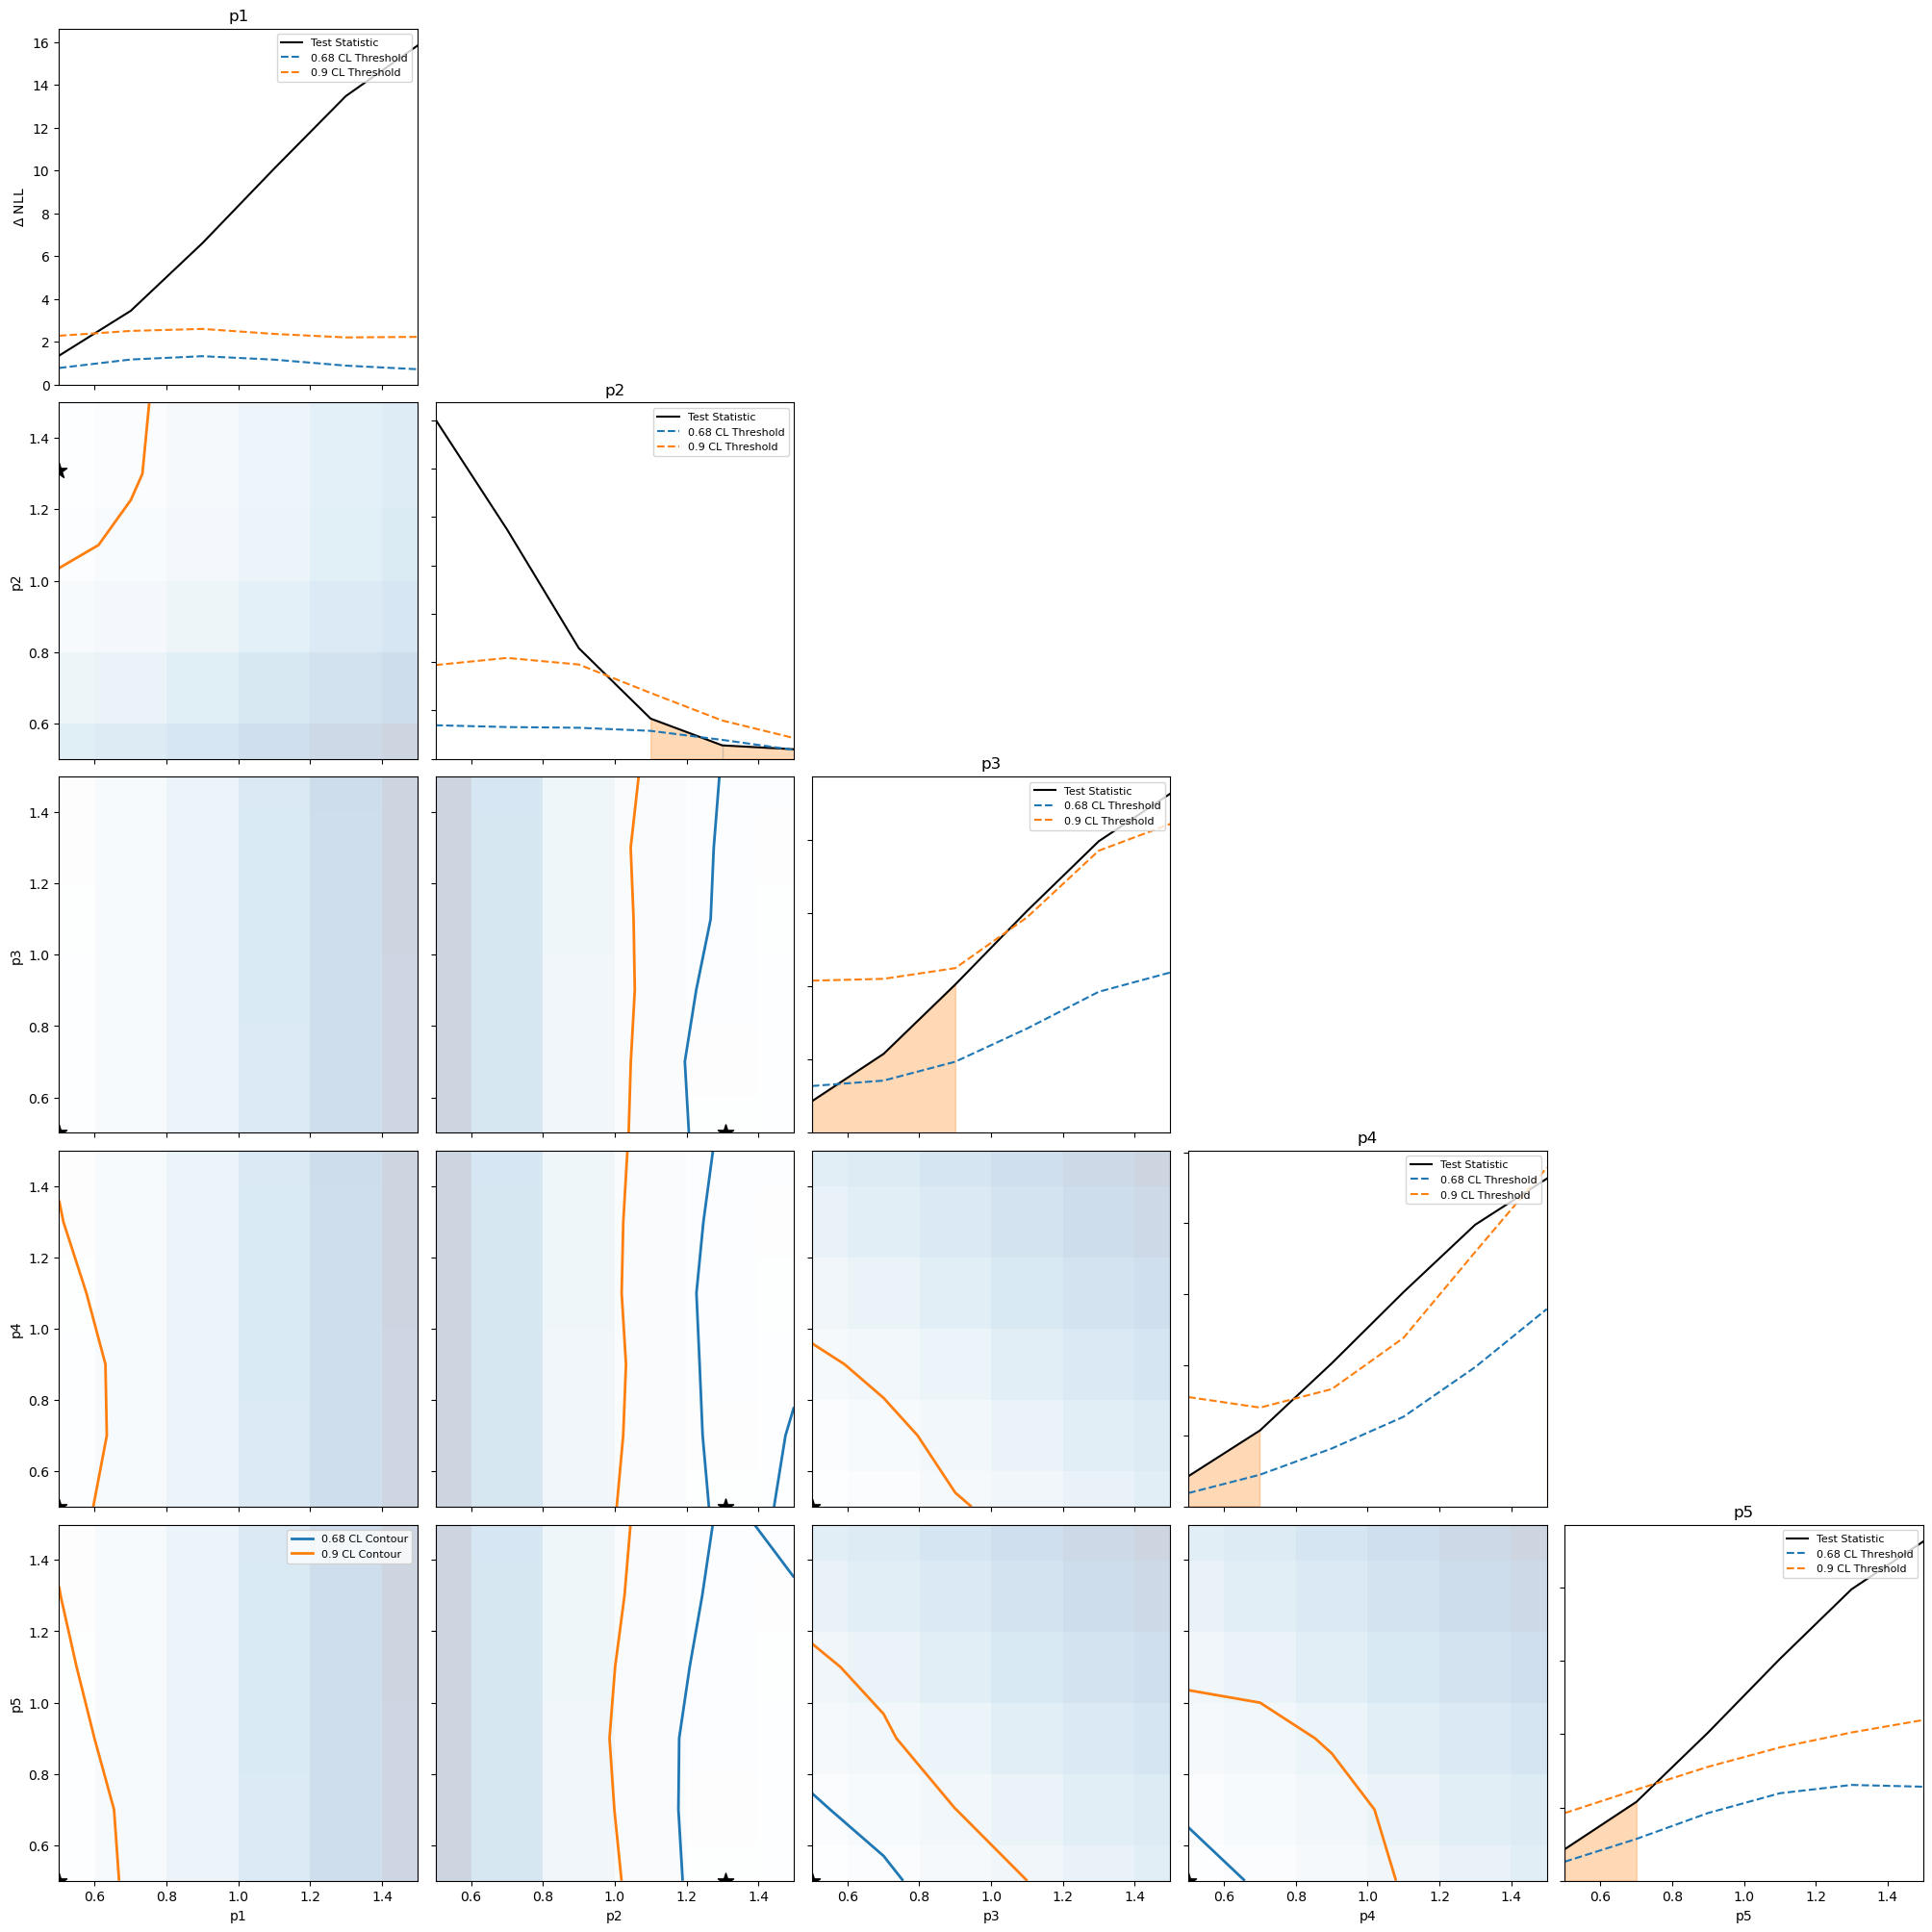

In [2]:
S_template_5p = np.array([0.1, 0.5, 2.0, 5.0, 3.0, 1.0])
B_template_5p = np.array([15.0, 5.0, 1.0, 0.1, 0.05, 0.01])
observed_counts_5p = np.array([20, 7, 2, 0, 1, 0])
ZERO_SUMW2_5P = np.zeros_like(S_template_5p)


@njit(fastmath=True, nogil=True)
def compute_rates_5p(params, S_sumw2, B_sumw2):
    mu = params[0] * S_template_5p + params[1] * B_template_5p
    for i in range(2, 5):
        mu += params[i] * 0.05   # 3 flat systematic shifts
    return mu, np.zeros_like(mu)   # finite-MC correction not exercised here


grids_5p = [np.linspace(0.501, 1.499, 6) for _ in range(5)]

print("Running 5-parameter binned analysis (1D + 2D)...")
results_5p, fig_5p = compute_fc_intervals(
    data=observed_counts_5p,
    grids=grids_5p,
    compute_rates_func=compute_rates_5p,
    likelihood_type="binned",
    S_sumw2=ZERO_SUMW2_5P, B_sumw2=ZERO_SUMW2_5P,
    cl=[0.68, 0.90],
    n_toys=N_TOYS,
    num_cores=CORES,
    verbose=0,
    sparsify_grid=False,
    compute_1D_intervals=True,
    compute_2D_intervals=True,   # C(5,2) = 10 pairs -- still cheap at this grid/n_toys size
    param_names=[f"p{i+1}" for i in range(5)],
    save_directory="high_dimensional_output/binned_5p",
)

print("\n--- 1D interval bounds (5-parameter) ---")
print_1d_bounds(results_5p, n_params=5, cl_list=[0.68, 0.90])
print(f"\n2D pairs actually computed: {len(results_5p) and sum(1 for k in results_5p if k.startswith('2d_t_data_'))}")

## 2. Ten parameters -- combinatorics, without paying for them

Bumping this same idea up to 10 parameters gives $\binom{10}{2} = 45$ distinct 2D pairs. At
*any* non-trivial grid resolution and toy count, running all 45 pairs would take a very long
time -- which is precisely the point being illustrated, not a limitation to work around. So
here we run **1D-only** (`compute_2D_intervals=False`) with a tiny grid and just 3 toys per
point, purely to confirm the profiling machinery itself scales cleanly to double-digit
parameter counts. For a real 10+ parameter analysis, you would either:

* restrict `compute_2D_intervals` to the handful of pairs you actually care about (there is no
  built-in "only these pairs" option today -- see `orchestrator.py`'s `itertools.combinations`
  call if you want to fork this behavior), or
* accept that a full pairwise 2D scan at this scale is a genuinely expensive HPC job (see the
  README's *HPC & Parallelization Guidelines* section).

Running 10-parameter binned analysis (1D only)...



--- 1D interval bounds (10-parameter, CL=0.90 only) ---
  param1:
    CL 0.9: [0.8333, 1.167]
  param2:
    CL 0.9: [0.8333, 0.8333]
  param3:
    CL 0.9: [0.5, 1.5]
  param4:
    CL 0.9: [0.5, 1.5]
  param5:
    CL 0.9: [0.5, 1.5]
  param6:
    CL 0.9: [0.5, 1.5]
  param7:
    CL 0.9: [0.5, 1.5]
  param8:
    CL 0.9: [0.8333, 1.5]
  param9:
    CL 0.9: [0.5, 1.5]
  param10:
    CL 0.9: [0.8333, 1.5]


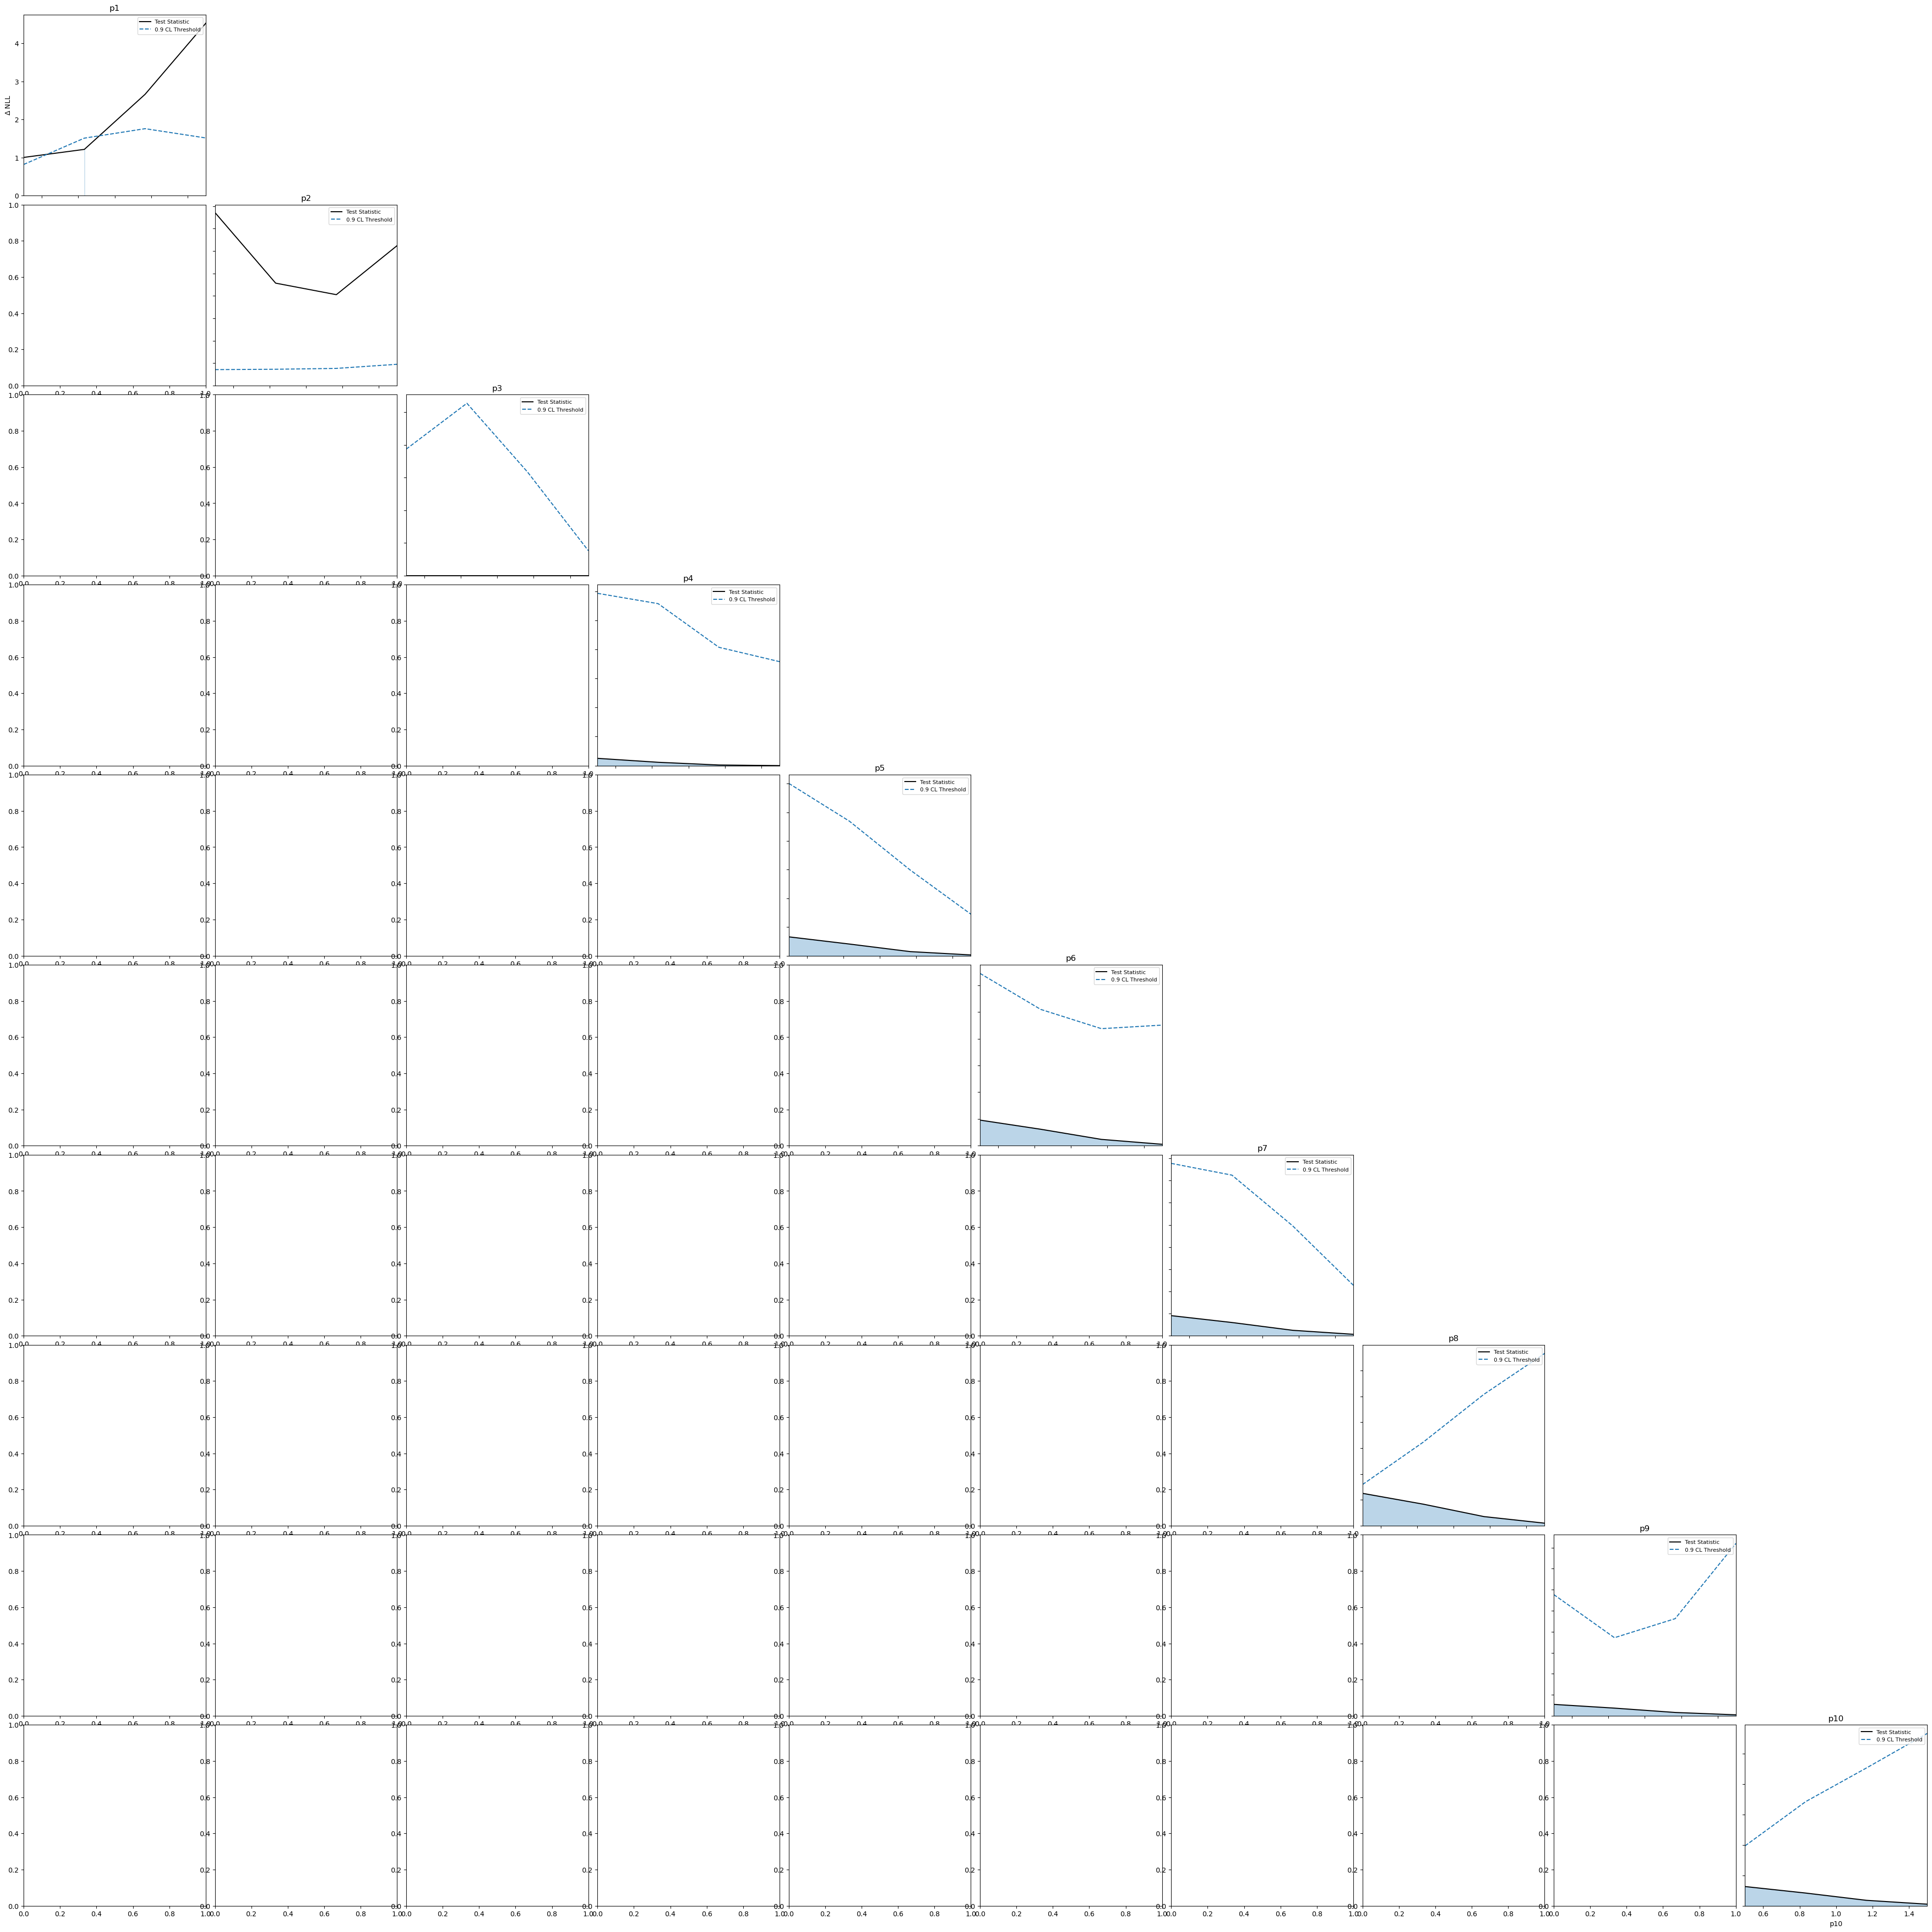

In [3]:
S_template_10p = np.linspace(0.1, 5.0, 15)
B_template_10p = np.linspace(15.0, 0.1, 15)

np.random.seed(42)
observed_counts_10p = np.random.poisson(S_template_10p + B_template_10p)
ZERO_SUMW2_10P = np.zeros_like(S_template_10p)

base_shape = np.linspace(0.1, 1.0, len(S_template_10p))


@njit(fastmath=True, nogil=True)
def compute_rates_10p(params, S_sumw2, B_sumw2):
    mu = params[0] * S_template_10p + params[1] * B_template_10p
    # Give each of the 8 remaining parameters a distinguishable structural
    # shape (a different power of the same base curve) so the fit can tell them apart.
    for i in range(2, 10):
        mu += params[i] * 0.05 * base_shape ** (i - 1)
    return mu, np.zeros_like(mu)


grids_10p = [np.linspace(0.5, 1.5, 4) for _ in range(10)]

print("Running 10-parameter binned analysis (1D only)...")
results_10p, _ = compute_fc_intervals(
    data=observed_counts_10p,
    grids=grids_10p,
    compute_rates_func=compute_rates_10p,
    likelihood_type="binned",
    S_sumw2=ZERO_SUMW2_10P, B_sumw2=ZERO_SUMW2_10P,
    cl=[0.90],
    n_toys=3,
    num_cores=CORES,
    verbose=0,
    sparsify_grid=False,
    compute_1D_intervals=True,
    compute_2D_intervals=False,   # 45 pairs -- deliberately skipped, see markdown above
    param_names=[f"p{i+1}" for i in range(10)],
    save_directory="high_dimensional_output/binned_10p",
)

print("\n--- 1D interval bounds (10-parameter, CL=0.90 only) ---")
print_1d_bounds(results_10p, n_params=10, cl_list=[0.90])

## Next steps

See `04_pyfc_algorithmic_features_tutorial.ipynb` for the `sparsify_grid` knob that makes
higher-resolution 2D scans tractable, and `05_pyfc_strategy_comparison_tutorial.ipynb` for how
the choice of optimizer strategy (`"grid"` vs `"scipy"` vs `"hybrid"`) affects runtime as
dimensionality grows.